# Geometric Brownian Motion (GBM) Simulation and Chart Foundations

##  1. GBM Model Definition

We model the stock price $S_t$ as a **Geometric Brownian Motion (GBM)**:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t
$$

Where:
- $\mu$: Drift (expected return)
- $\sigma$: Volatility
- $W_t$: Standard Brownian motion
- $S_0$: Initial stock price

The solution is:

$$
S_t = S_0 \exp\left( \left( \mu - \frac{1}{2} \sigma^2 \right)t + \sigma W_t \right)
$$

Discretized as:

$$
S_{t+\Delta t} = S_t \cdot \exp\left( \left( \mu - \frac{1}{2} \sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} \cdot Z_t \right)
$$

Where $Z_t \sim \mathcal{N}(0, 1)$.

---

## Plot 1: Simulated Stock Price Path

Visualizes the GBM path $S_t$ over 5 years.

---

## Plot 2: Annualized Daily Log Returns

Log returns:

$$
r_t = \log\left( \frac{S_t}{S_{t-1}} \right)
$$

Annualized:

$$
r_t^{\text{ann}} = r_t \times 252
$$

---

## Plot 3: Histogram of Log Returns with Normal PDF

Normal PDF:

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)
$$

Overlay this on a histogram of $r_t^{\text{ann}}$.

---

## Plot 4: Rolling Realized Volatility

Windowed estimate:

1. Centered squared returns:
   $$
   s_t = \left( r_t - \bar{r} \right)^2
   $$
2. Moving average:
   $$
   \hat{\sigma}^2_t = \frac{1}{N} \sum_{i=t-N+1}^t s_i
   $$
3. Annualize:
   $$
   \text{Realized Volatility}_t = \sqrt{252 \cdot \hat{\sigma}^2_t}
   $$

---

## Plot 5: Q-Q Plot

Quantile-quantile plot of $r_t^{\text{ann}}$ vs. normal distribution. A straight line implies normality.

---

## Plot 6: Cumulative Realized Volatility

Cumulative realized variance:

$$
\hat{\sigma}^2_{\text{cumulative}}(t) = \frac{252}{t} \sum_{i=1}^t r_i^2
$$

Cumulative realized volatility:

$$
\hat{\sigma}_{\text{cumulative}}(t) = \sqrt{ \hat{\sigma}^2_{\text{cumulative}}(t) }
$$

This reflects how volatility estimation stabilizes with more data.

---

## Summary

Each plot is based on solid financial and statistical principles. This framework enables realistic stock path simulation and empirical volatility analysis.



Annualized Log Return Statistics:
Mean: -0.10601
Std Dev: 3.20945
Skewness: 0.00126
Kurtosis: -0.04730


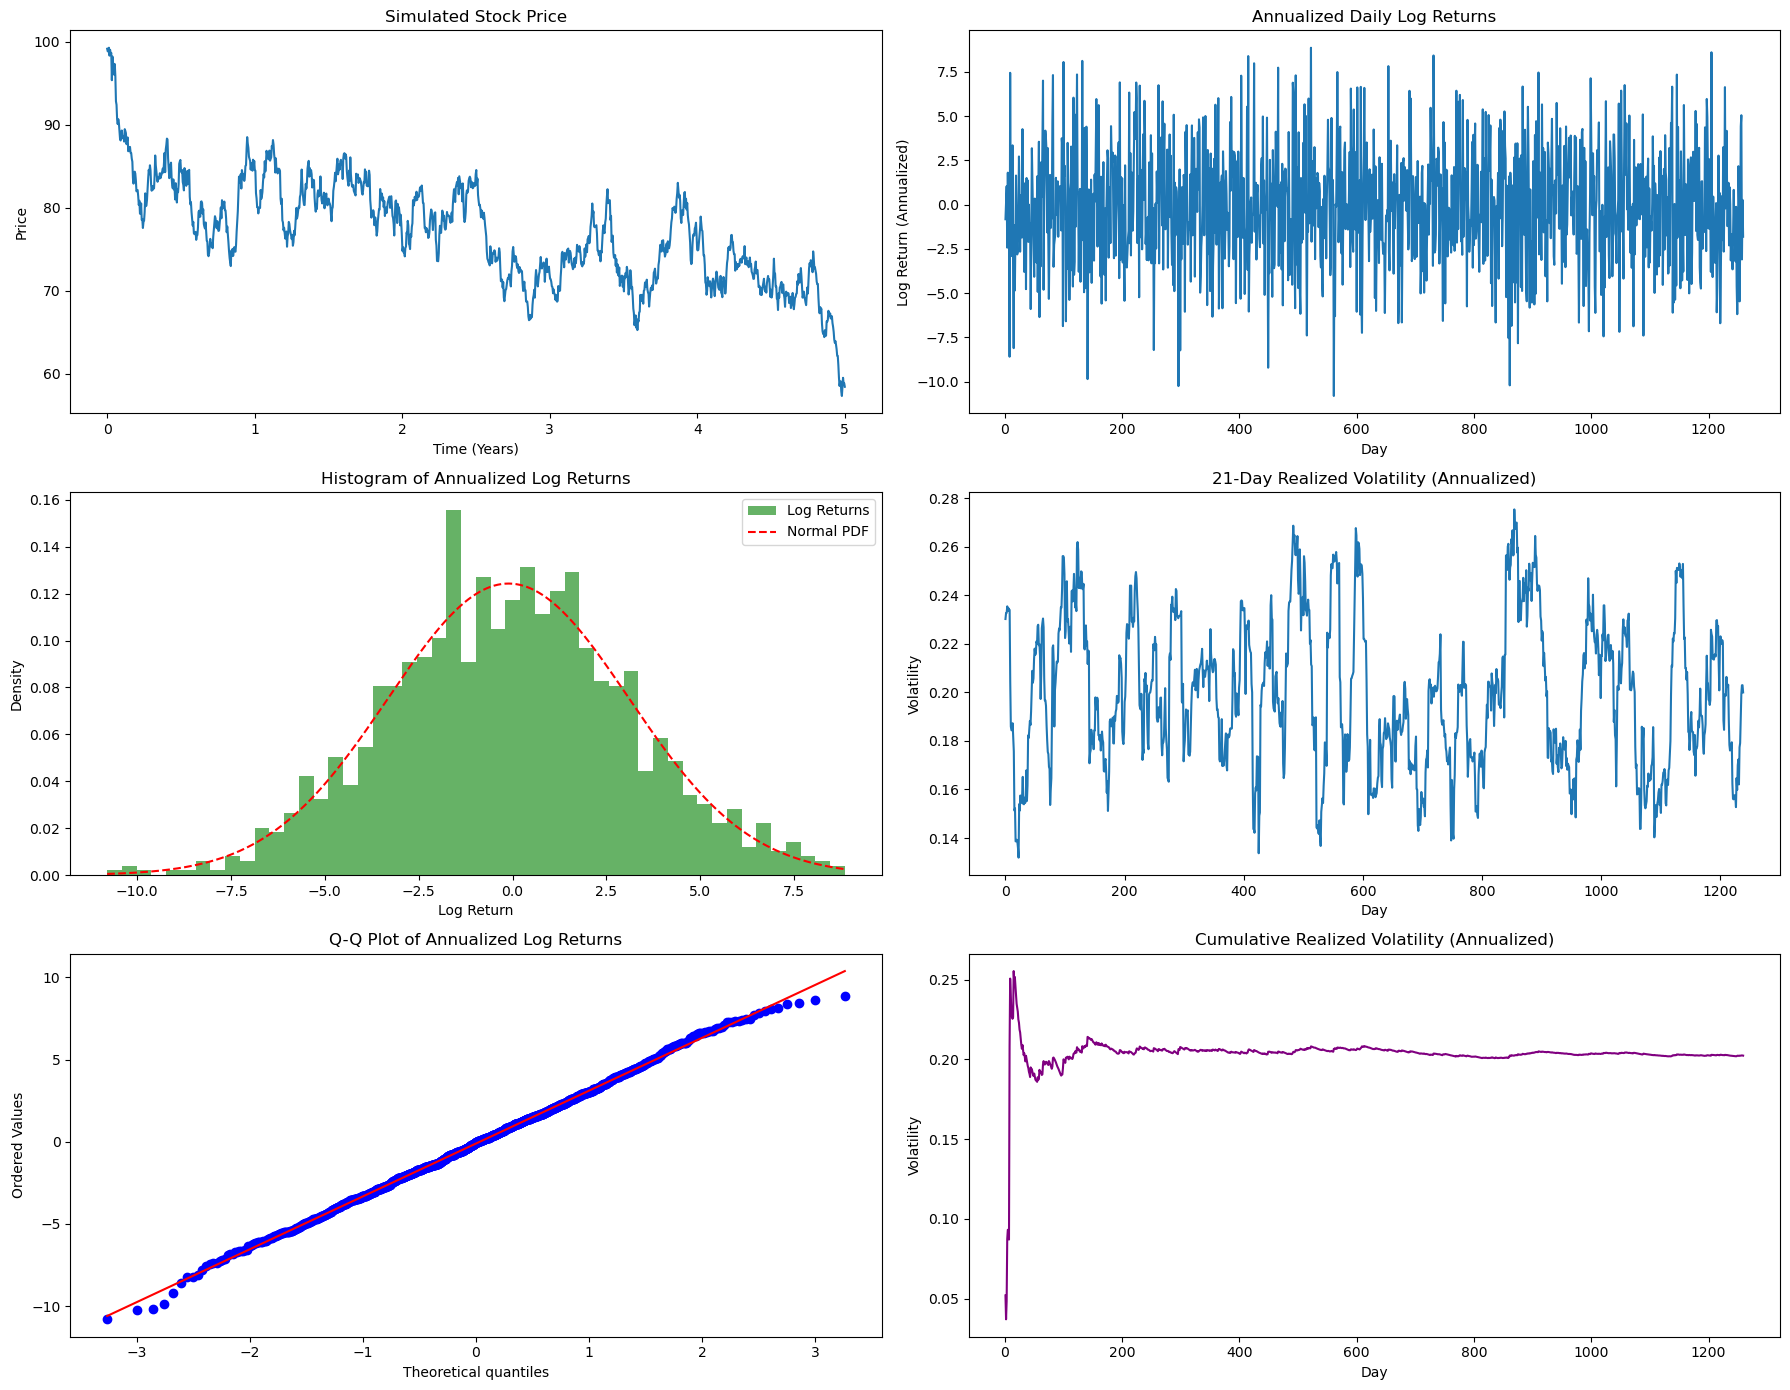

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

# --- Function 1: PDF of normal distribution ---
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# --- Function 2: GBM Simulation ---
def simulate_gbm(S0, T, r, sigma):
    N = int(T * 252)
    dt = 1 / 252
    t = np.linspace(0, T, N)
    Z = np.random.normal(0, 1, N)
    W = np.cumsum(np.sqrt(dt) * Z)
    S = S0 * np.exp((r - 0.5 * sigma**2) * t + sigma * W)
    return t, S

# === Parameters ===
S0 = 100
T = 5
r = 0.05
sigma = 0.2
rolling_window = 21
annualization_factor = 252

# === Simulate GBM path ===
t, S = simulate_gbm(S0, T, r, sigma)
log_returns = np.diff(np.log(S))
annualized_daily_log_returns = log_returns * annualization_factor
dates = np.arange(1, len(S))

# === Build DataFrame ===
gbm = pd.DataFrame({'Price': S[1:], 'LogReturn': log_returns}, index=dates)

# === Realized (rolling) volatility: standard method ===
rolling_var = np.convolve(
    (log_returns - np.mean(log_returns)) ** 2,
    np.ones(rolling_window) / rolling_window,
    mode='valid'
)
realized_vol = np.sqrt(annualization_factor) * np.sqrt(rolling_var)

# === Cumulative realized variance (annualized) ===
gbm['RealizedVariance'] = annualization_factor * np.cumsum(gbm['LogReturn'] ** 2) / np.arange(1, len(gbm) + 1)

# === Take square root to get cumulative realized volatility ===
gbm['CumulativeVolatility'] = np.sqrt(gbm['RealizedVariance'])

# === Print statistics ===
print("Annualized Log Return Statistics:")
print(f"Mean: {np.mean(annualized_daily_log_returns):.5f}")
print(f"Std Dev: {np.std(annualized_daily_log_returns):.5f}")
print(f"Skewness: {stats.skew(annualized_daily_log_returns):.5f}")
print(f"Kurtosis: {stats.kurtosis(annualized_daily_log_returns):.5f}")

# === Plotting ===
plt.figure(figsize=(18, 14))

# Plot 1: Simulated stock price
plt.subplot(3, 2, 1)
plt.plot(t, S)
plt.title('Simulated Stock Price')
plt.xlabel('Time (Years)')
plt.ylabel('Price')

# Plot 2: Annualized daily log returns
plt.subplot(3, 2, 2)
plt.plot(dates, annualized_daily_log_returns)
plt.title('Annualized Daily Log Returns')
plt.xlabel('Day')
plt.ylabel('Log Return (Annualized)')

# Plot 3: Histogram of annualized log returns with normal overlay
plt.subplot(3, 2, 3)
count, bins, ignored = plt.hist(annualized_daily_log_returns, bins=50, density=True, alpha=0.6, color='g', label='Log Returns')
x_vals = np.linspace(min(annualized_daily_log_returns), max(annualized_daily_log_returns), 1000)
plt.plot(x_vals, normal_pdf(x_vals, np.mean(annualized_daily_log_returns), np.std(annualized_daily_log_returns)), 'r--', label='Normal PDF')
plt.title('Histogram of Annualized Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()

# Plot 4: Rolling realized volatility (21-day)
plt.subplot(3, 2, 4)
plt.plot(np.arange(len(realized_vol)), realized_vol)
plt.title(f'{rolling_window}-Day Realized Volatility (Annualized)')
plt.xlabel('Day')
plt.ylabel('Volatility')

# Plot 5: Q-Q Plot
plt.subplot(3, 2, 5)
stats.probplot(annualized_daily_log_returns, dist="norm", plot=plt)
plt.title('Q-Q Plot of Annualized Log Returns')

# ✅ Plot 6: Cumulative realized volatility
plt.subplot(3, 2, 6)
plt.plot(gbm.index, gbm['CumulativeVolatility'], color='purple')
plt.title('Cumulative Realized Volatility (Annualized)')
plt.xlabel('Day')
plt.ylabel('Volatility')

plt.tight_layout()
plt.show()
